In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
df = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [14]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26      

In [15]:
print("\nDataset Information:")
df.info()




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

In [16]:
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


Total Missing Values:
0


In [17]:
# Remove rows containing NaN values
df = df.dropna().reset_index(drop=True)

print("\nDataset Shape After Removing NaN:")
print(df.shape)



Dataset Shape After Removing NaN:
(284807, 31)


In [18]:
# 6. CLASS DISTRIBUTION
# ============================================

print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nClass Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [19]:
# 7. SEPARATE X AND Y
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (284807, 30)
y Shape: (284807,)


In [20]:

# 8. TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (227845, 30)
Testing Shape: (56962, 30)


In [21]:
# 9. SCALE DATA
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
# 10. APPLY SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [24]:
# 11. LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
# 12. PREDICTIONS
# ============================================

y_pred = model.predict(X_test_scaled)

# Probability of fraud
y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]



In [26]:
# 13. CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962




Confusion Matrix:
[[55397  1467]
 [    8    90]]


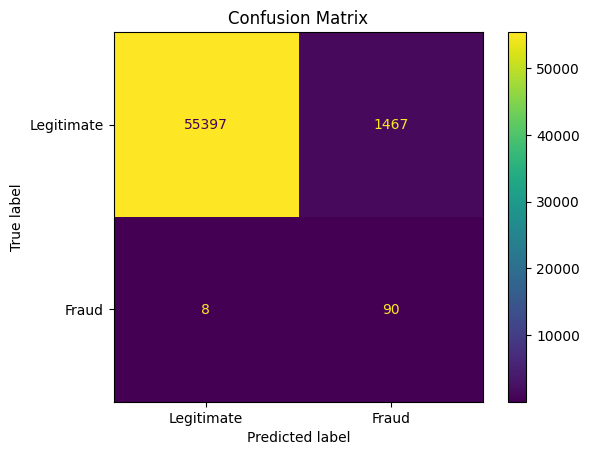

In [27]:
# 14. CONFUSION MATRIX
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Confusion Matrix")
plt.show()

In [28]:
# 15. METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nModel Metrics:")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


Model Metrics:
Accuracy : 0.9741055440469084
Precision: 0.057803468208092484
Recall   : 0.9183673469387755
F1 Score : 0.10876132930513595
ROC-AUC  : 0.9708434302252134


In [29]:
# 16. THRESHOLD TUNING
# ============================================

thresholds = np.arange(
    0.05,
    1.00,
    0.01
)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    f1_value = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    if f1_value > best_f1:

        best_f1 = f1_value
        best_threshold = threshold

print("\nBest Threshold:", best_threshold)
print("Best F1 Score:", best_f1)


Best Threshold: 0.9900000000000002
Best F1 Score: 0.6771653543307087


In [30]:


# 17. BEST THRESHOLD PREDICTION


y_pred_best = (
    y_prob >= best_threshold
).astype(int)

print("\nClassification Report Using Best Threshold:")

print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)


Classification Report Using Best Threshold:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962




Best Threshold Confusion Matrix:
[[56794    70]
 [   12    86]]


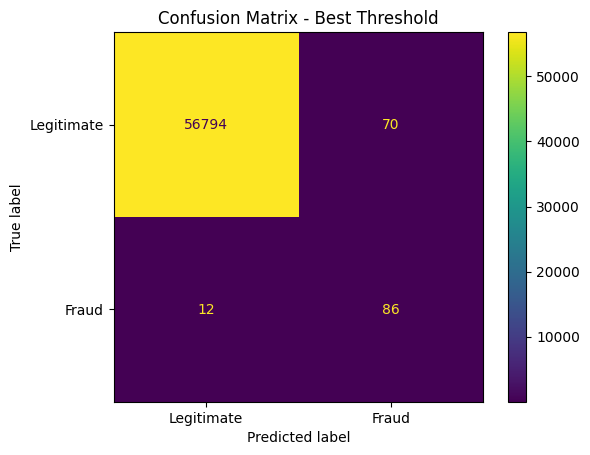

In [31]:
# 18. BEST THRESHOLD CONFUSION MATRIX
# ============================================

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)

print("\nBest Threshold Confusion Matrix:")
print(cm_best)

ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Confusion Matrix - Best Threshold")

plt.show()

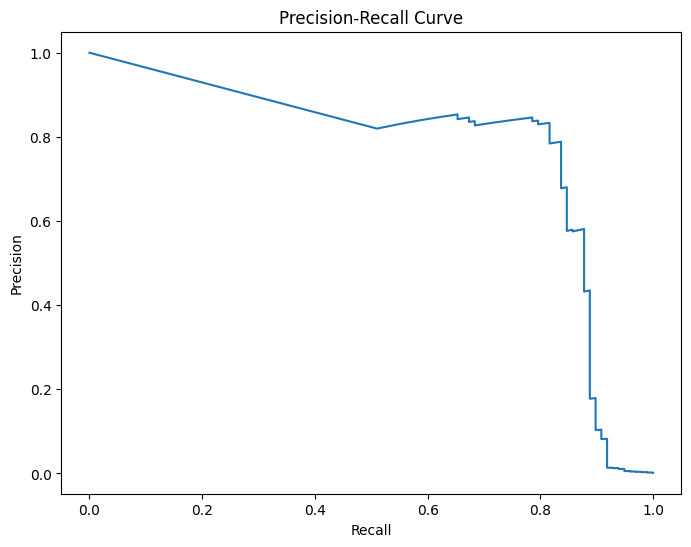

In [32]:
# 22. PRECISION-RECALL CURVE
# ============================================

from sklearn.metrics import precision_recall_curve

precision_values, recall_values, threshold_values = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

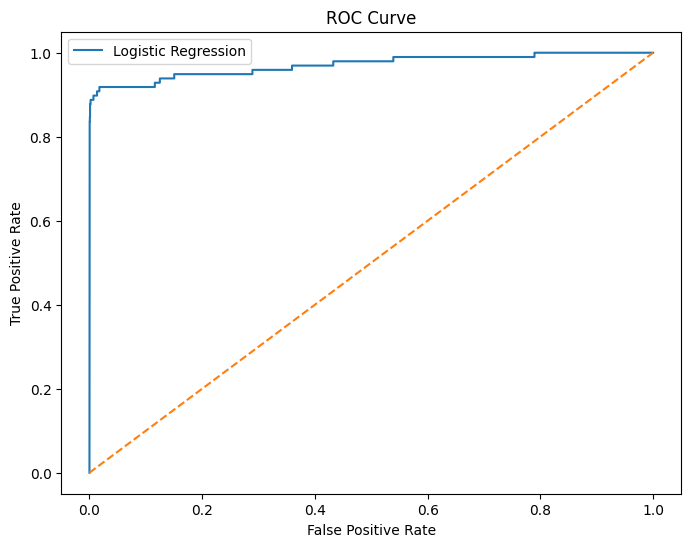

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
